<a href="https://colab.research.google.com/github/stephenkeyy77/ECON3916-Statistical-Machine-Learning/blob/main/Lab%204/Lab_4_Descriptive_statistics_%26_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


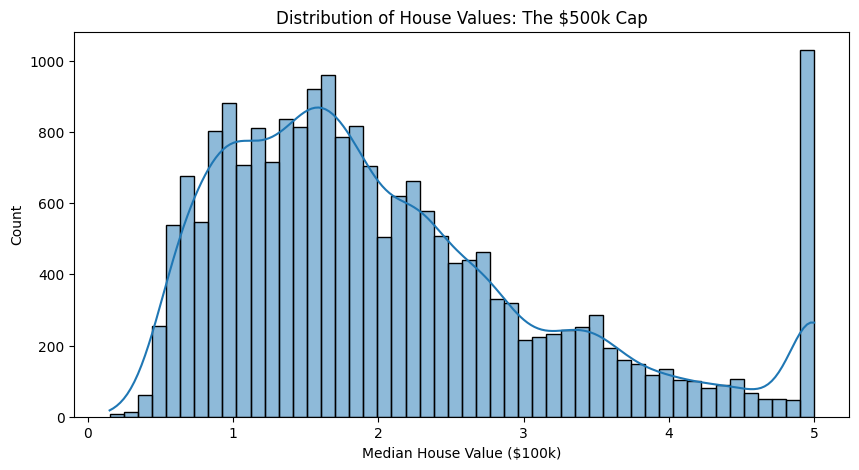

In [11]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Ingest Data
data = fetch_california_housing(as_frame=True)
df = data.frame
df.describe()

# 2. Inspect the "Ceiling Effect"
print(df['MedHouseVal'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title("Distribution of House Values: The $500k Cap")
plt.xlabel("Median House Value ($100k)")
plt.show()



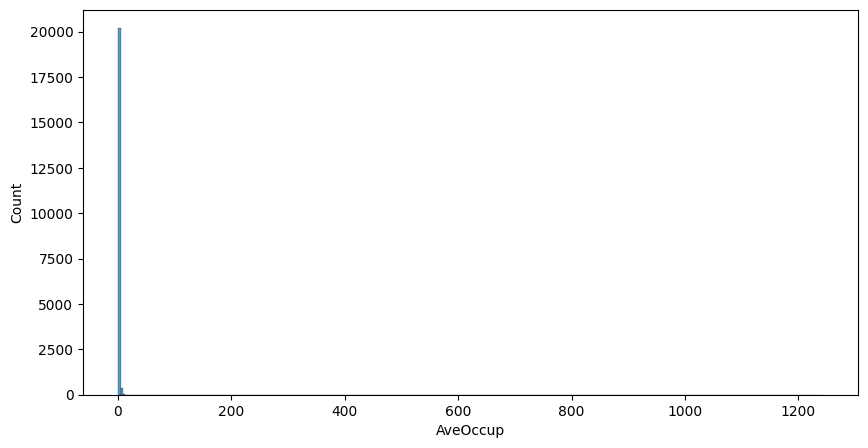

In [15]:
plt.figure(figsize=(10, 5))
sns.histplot(df['AveOccup'], bins = 300)
plt.show()


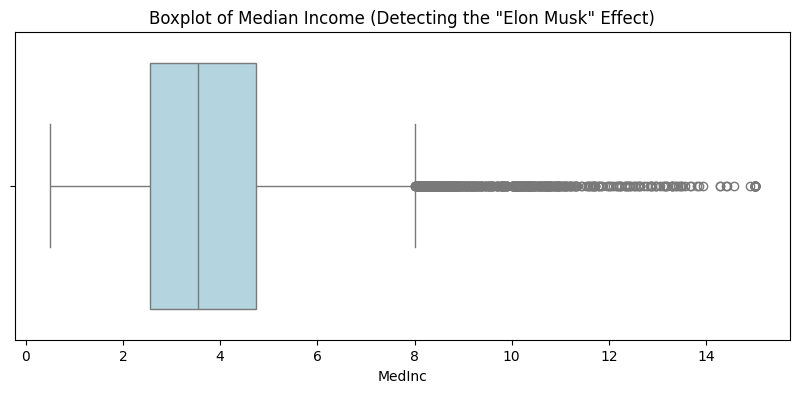

In [16]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['MedInc'], color='lightblue')
plt.title('Boxplot of Median Income (Detecting the "Elon Musk" Effect)')
plt.show()

In [17]:
# Initialize the model
# contamination=0.05: We estimate ~5% of the data is anomalous
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=3916)

# Features to analyze (Income, House Age, Average Rooms)
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']

# Fit and Predict (-1 = Outlier, 1 = Normal)
preds = iso_forest.fit_predict(df[features])

# Map to boolean (True if outlier)
df['outlier_iso'] = preds == -1

print(f"Algorithmic Outliers Detected: {df['outlier_iso'].sum()}")

Algorithmic Outliers Detected: 1032


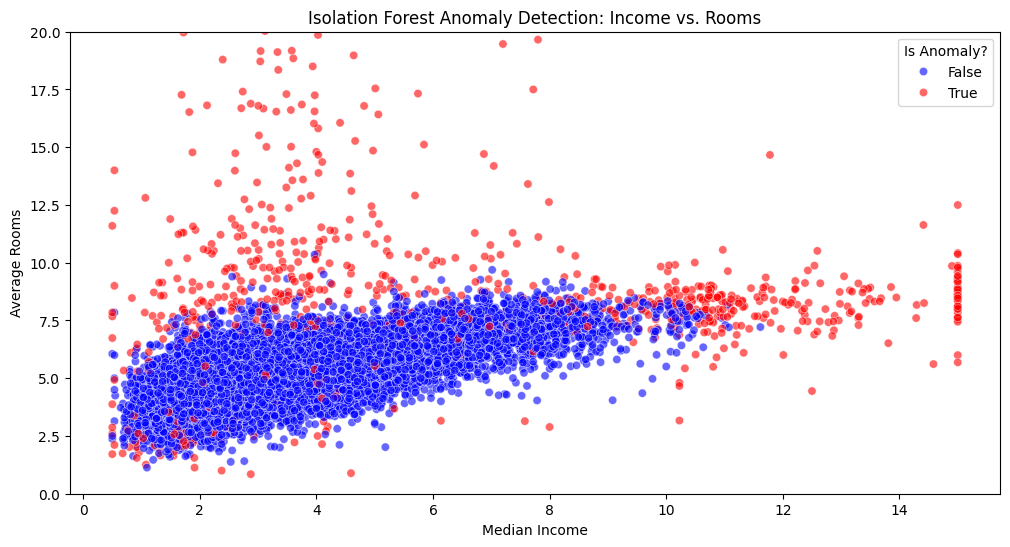

In [18]:
plt.figure(figsize=(12, 6))

# Plot points flagged by Isolation Forest
sns.scatterplot(
    data=df,
    x='MedInc',
    y='AveRooms',
    hue='outlier_iso',
    palette={True: 'red', False: 'blue'},
    alpha=0.6
)

plt.title("Isolation Forest Anomaly Detection: Income vs. Rooms")
plt.xlabel("Median Income")
plt.ylabel("Average Rooms")
plt.ylim(0, 20) # Zoom in to ignore extreme errors
plt.legend(title='Is Anomaly?')
plt.show()

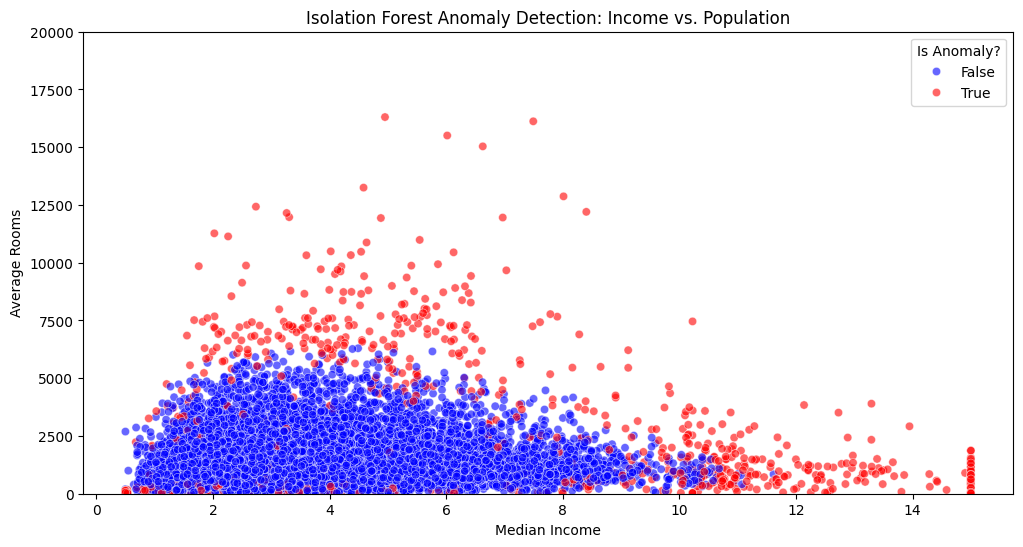

In [22]:
plt.figure(figsize=(12, 6))

# Plot points flagged by Isolation Forest
sns.scatterplot(
    data=df,
    x='MedInc',
    y='Population',
    hue='outlier_iso',
    palette={True: 'red', False: 'blue'},
    alpha=0.6
)

plt.title("Isolation Forest Anomaly Detection: Income vs. Population")
plt.xlabel("Median Income")
plt.ylabel("Average Rooms")
plt.ylim(0, 20000) # Zoom in to ignore extreme errors
plt.legend(title='Is Anomaly?')
plt.show()

Dataset Split:
  Normal Observations: 19,608
  Outlier Observations: 1,032
  Outlier Rate: 5.00%

COMPARATIVE FORENSICS REPORT: NORMAL vs OUTLIERS

📊 CENTRAL TENDENCY ANALYSIS
----------------------------------------------------------------------
   Group  MedInc_Mean  MedInc_Median  MedHouseVal_Mean  MedHouseVal_Median
  Normal     3.748163        3.50555          2.031344               1.785
Outliers     6.198318        4.88845          2.775622               2.250

📈 VOLATILITY COMPARISON: Standard Deviation vs MAD
----------------------------------------------------------------------
   Group  MedInc_SD  MedInc_MAD  MedHouseVal_SD  MedHouseVal_MAD
  Normal   1.622705     1.03335        1.109361            0.671
Outliers   4.058093     2.58750        1.650955            1.250

⚖️  INEQUALITY WEDGE: Mean - Median Gap Analysis
----------------------------------------------------------------------
(Positive wedge → Right skew → Wealth concentration in upper tail)
   Variable  Normal_We

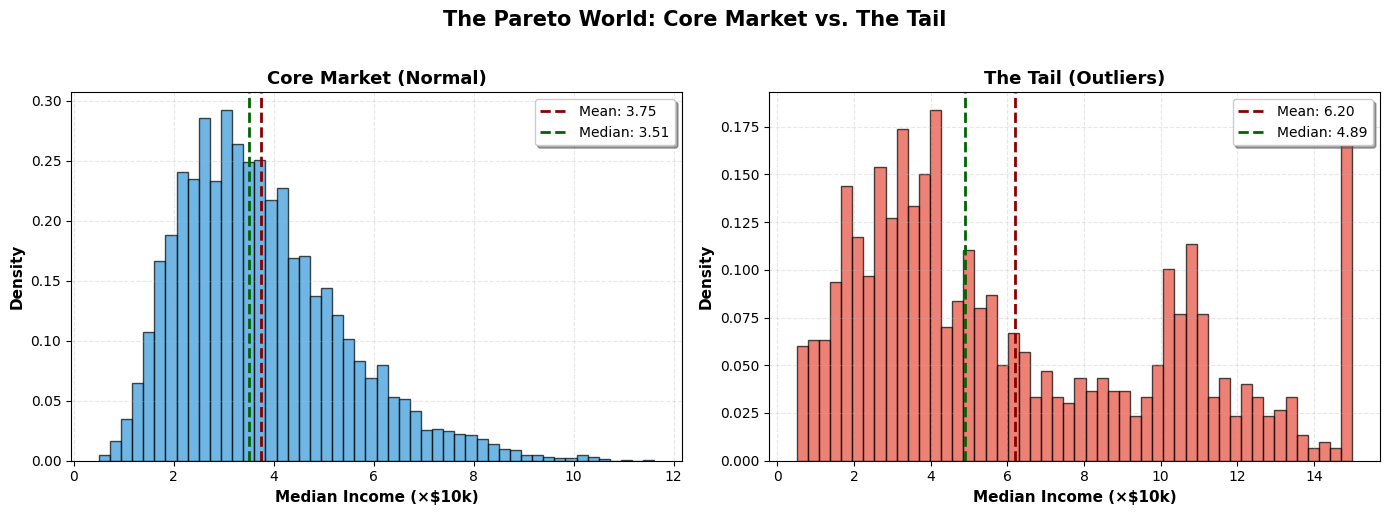


Report Complete. Visual comparison displayed above.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

# ============================================================
# TASK 1: Split Data into Normal and Outlier Groups
# ============================================================
df_normal = df[df['outlier_iso'] == False].copy()
df_outlier = df[df['outlier_iso'] == True].copy()

print(f"Dataset Split:")
print(f"  Normal Observations: {len(df_normal):,}")
print(f"  Outlier Observations: {len(df_outlier):,}")
print(f"  Outlier Rate: {len(df_outlier)/len(df)*100:.2f}%\n")

# ============================================================
# TASK 2: Calculate Mean and Median for Both Variables
# ============================================================
def calculate_central_tendencies(df_group, group_name):
    """Calculate mean and median for income and house value"""
    results = {
        'Group': group_name,
        'MedInc_Mean': df_group['MedInc'].mean(),
        'MedInc_Median': df_group['MedInc'].median(),
        'MedHouseVal_Mean': df_group['MedHouseVal'].mean(),
        'MedHouseVal_Median': df_group['MedHouseVal'].median()
    }
    return results

normal_stats = calculate_central_tendencies(df_normal, 'Normal')
outlier_stats = calculate_central_tendencies(df_outlier, 'Outliers')

# ============================================================
# TASK 3: Calculate Volatility Measures (SD vs MAD)
# ============================================================
def calculate_dispersion_metrics(df_group, group_name):
    """Calculate standard deviation and MAD for robustness comparison"""
    results = {
        'Group': group_name,
        'MedInc_SD': df_group['MedInc'].std(),
        'MedInc_MAD': median_abs_deviation(df_group['MedInc'], nan_policy='omit'),
        'MedHouseVal_SD': df_group['MedHouseVal'].std(),
        'MedHouseVal_MAD': median_abs_deviation(df_group['MedHouseVal'], nan_policy='omit')
    }
    return results

normal_dispersion = calculate_dispersion_metrics(df_normal, 'Normal')
outlier_dispersion = calculate_dispersion_metrics(df_outlier, 'Outliers')

# ============================================================
# TASK 4: Calculate "Inequality Wedge" (Mean - Median)
# ============================================================
# The wedge measures right-skewness: positive values indicate
# concentration in the upper tail (Pareto-style distributions)

inequality_wedge = pd.DataFrame({
    'Variable': ['MedInc', 'MedHouseVal'],
    'Normal_Wedge': [
        normal_stats['MedInc_Mean'] - normal_stats['MedInc_Median'],
        normal_stats['MedHouseVal_Mean'] - normal_stats['MedHouseVal_Median']
    ],
    'Outlier_Wedge': [
        outlier_stats['MedInc_Mean'] - outlier_stats['MedInc_Median'],
        outlier_stats['MedHouseVal_Mean'] - outlier_stats['MedHouseVal_Median']
    ]
})

inequality_wedge['Wedge_Ratio'] = (
    inequality_wedge['Outlier_Wedge'] / inequality_wedge['Normal_Wedge']
)

# ============================================================
# COMPREHENSIVE FORENSICS REPORT
# ============================================================
print("="*70)
print("COMPARATIVE FORENSICS REPORT: NORMAL vs OUTLIERS")
print("="*70)

print("\n📊 CENTRAL TENDENCY ANALYSIS")
print("-"*70)
summary_df = pd.DataFrame([normal_stats, outlier_stats])
print(summary_df.to_string(index=False))

print("\n📈 VOLATILITY COMPARISON: Standard Deviation vs MAD")
print("-"*70)
dispersion_df = pd.DataFrame([normal_dispersion, outlier_dispersion])
print(dispersion_df.to_string(index=False))

print("\n⚖️  INEQUALITY WEDGE: Mean - Median Gap Analysis")
print("-"*70)
print("(Positive wedge → Right skew → Wealth concentration in upper tail)")
print(inequality_wedge.to_string(index=False))

print("\n🔍 KEY INSIGHTS:")
print("-"*70)
print(f"1. Income Dispersion Ratio (Outlier SD / Normal SD): "
      f"{outlier_dispersion['MedInc_SD']/normal_dispersion['MedInc_SD']:.2f}x")
print(f"2. Value Dispersion Ratio (Outlier SD / Normal SD): "
      f"{outlier_dispersion['MedHouseVal_SD']/normal_dispersion['MedHouseVal_SD']:.2f}x")
print(f"3. Outlier Income Wedge Amplification: "
      f"{inequality_wedge.loc[0, 'Wedge_Ratio']:.2f}x larger than normal")
print(f"4. Robustness Check: MAD/SD ratio shows {'heavy' if outlier_dispersion['MedInc_MAD']/outlier_dispersion['MedInc_SD'] < 0.6 else 'moderate'} tail influence")

# ============================================================
# VISUALIZATION: The Pareto World
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Panel: Normal Distribution
axes[0].hist(df_normal['MedInc'], bins=50, color='#3498db',
             edgecolor='black', alpha=0.7, density=True)
axes[0].axvline(normal_stats['MedInc_Mean'], color='darkred',
                linestyle='--', linewidth=2, label=f"Mean: {normal_stats['MedInc_Mean']:.2f}")
axes[0].axvline(normal_stats['MedInc_Median'], color='darkgreen',
                linestyle='--', linewidth=2, label=f"Median: {normal_stats['MedInc_Median']:.2f}")
axes[0].set_xlabel('Median Income (×$10k)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Density', fontsize=11, fontweight='bold')
axes[0].set_title('Core Market (Normal)', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True, shadow=True)
axes[0].grid(alpha=0.3, linestyle='--')

# Right Panel: Outlier Distribution
axes[1].hist(df_outlier['MedInc'], bins=50, color='#e74c3c',
             edgecolor='black', alpha=0.7, density=True)
axes[1].axvline(outlier_stats['MedInc_Mean'], color='darkred',
                linestyle='--', linewidth=2, label=f"Mean: {outlier_stats['MedInc_Mean']:.2f}")
axes[1].axvline(outlier_stats['MedInc_Median'], color='darkgreen',
                linestyle='--', linewidth=2, label=f"Median: {outlier_stats['MedInc_Median']:.2f}")
axes[1].set_xlabel('Median Income (×$10k)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Density', fontsize=11, fontweight='bold')
axes[1].set_title('The Tail (Outliers)', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True, shadow=True)
axes[1].grid(alpha=0.3, linestyle='--')

plt.suptitle('The Pareto World: Core Market vs. The Tail',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Report Complete. Visual comparison displayed above.")
print("="*70)